Part 1: Notebook Setup


# End-to-End Sales Forecasting & Demand Intelligence System

### Internship Project – Week 3 & Week 4

**Name:** Amisha Malhotra

This project develops an end-to-end sales forecasting and demand intelligence system using the Superstore Sales dataset. The workflow includes exploratory data analysis, time series decomposition, forecasting using SARIMA, Prophet, and XGBoost, anomaly detection, product demand segmentation using clustering, and deployment of an interactive Streamlit dashboard.

Cell 2 – Install Required Libraries

In [ ]:
!pip -q install prophet
!pip -q install xgboost
!pip -q install statsmodels
!pip -q install plotly

Cell 3 – Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet

from xgboost import XGBRegressor

sns.set_style("whitegrid")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


Cell 4 – Upload Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train (1).csv


Cell 5 – Load Dataset

In [ ]:
df = pd.read_csv("train.csv")

print("Dataset Loaded Successfully!")
print()

print("Shape :", df.shape)

df.head()

Dataset Loaded Successfully!

Shape : (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


Cell 6 – Dataset Overview

In [ ]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)

display(df.info())

print()

display(df.describe(include='all'))

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   f

None

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


Cell 7 – Check Missing Values

In [ ]:
missing = df.isnull().sum()

missing = missing[missing>0]

print(missing)

Postal Code    11
dtype: int64


Cell 8 – Duplicate Records

In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


Cell 9 – Convert Dates

In [ ]:

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

print("Date columns converted successfully!\n")

print(df[['Order Date', 'Ship Date']].head())

Date columns converted successfully!

  Order Date  Ship Date
0 2017-11-08 2017-11-11
1 2017-11-08 2017-11-11
2 2017-06-12 2017-06-16
3 2016-10-11 2016-10-18
4 2016-10-11 2016-10-18


Cell 10 – Feature Engineering

In [ ]:

df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Month Name"] = df["Order Date"].dt.month_name()

df["Quarter"] = df["Order Date"].dt.quarter

df["Week"] = df["Order Date"].dt.isocalendar().week

df["Day"] = df["Order Date"].dt.day_name()

df["Day Number"] = df["Order Date"].dt.day

def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Year,Month,Month Name,Quarter,Week,Day,Day Number,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,Wednesday,8,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,Wednesday,8,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,Monday,12,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,Tuesday,11,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,Tuesday,11,Autumn


Cell 11 – Final Data Check

In [ ]:
print(df.head())

print()

print(df.shape)

print()

print(df.columns)

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12 2017-06-16    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

                                        Product Name     Sales  Year Month  \
0                  Bush So

In [ ]:
import os

os.makedirs("charts", exist_ok=True)

print("Charts folder created successfully!")

Charts folder created successfully!


# Task 2: Time Series Analysis & Decomposition

In this section, we analyze the overall monthly sales trend over the four-year period. We decompose the time series into trend, seasonal, and residual components, test for stationarity using the Augmented Dickey-Fuller (ADF) test, and apply differencing if necessary.

Cell 2 – Create Monthly Sales Time Series

In [ ]:
monthly_sales = (
    df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales']
      .sum()
)

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


Cell 3 – Monthly Sales Trend

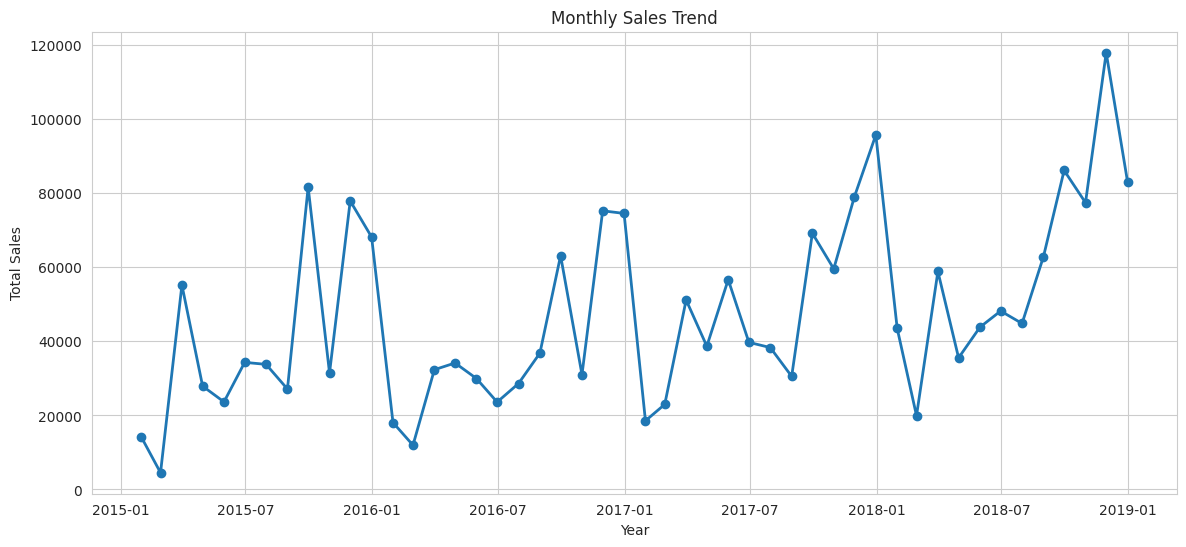

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=2
)

plt.title("Monthly Sales Trend")

plt.xlabel("Year")

plt.ylabel("Total Sales")

plt.grid(True)

plt.savefig(
    "charts/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Cell 4 – Seasonal Decomposition

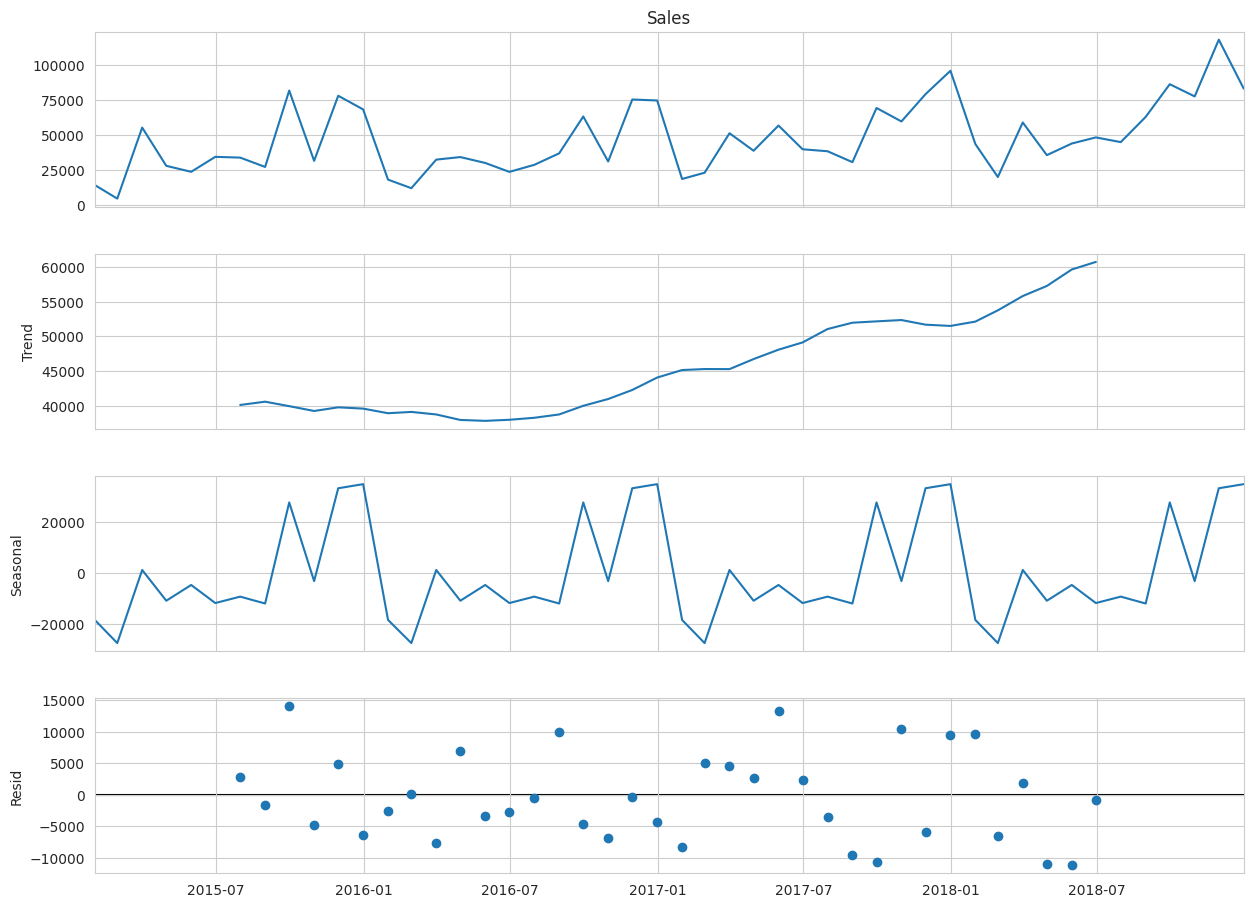

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_sales,
    model='additive',
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(14,10)

fig.savefig(
    "charts/time_series_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Cell 5 – Markdown

### Observations

- The trend component shows the long-term movement in sales.
- The seasonal component highlights recurring yearly patterns.
- The residual component represents random fluctuations not explained by trend or seasonality.
- Seasonal peaks may correspond to festive shopping periods and year-end sales.

Cell 6 – ADF Test

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print()

for key, value in result[4].items():
    print(f"Critical Value ({key}) : {value:.4f}")

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

Critical Value (1%) : -3.5778
Critical Value (5%) : -2.9253
Critical Value (10%) : -2.6008


Cell 7 – Interpretation

In [ ]:
if result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is NOT stationary.")

The series is stationary.


Cell 8 – Differencing

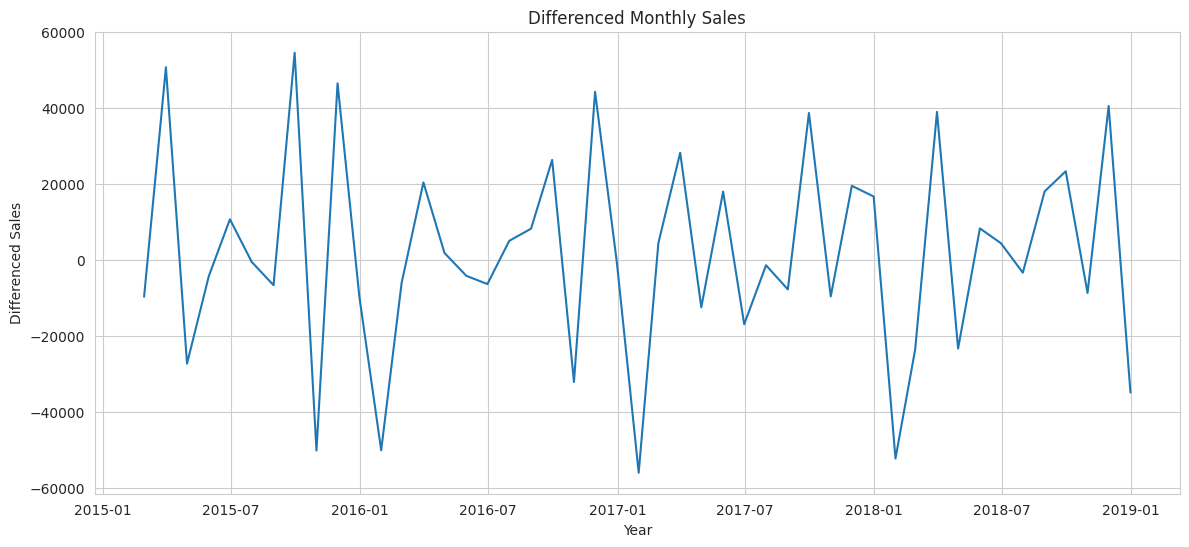

In [ ]:
monthly_diff = monthly_sales.diff().dropna()

plt.figure(figsize=(14,6))

plt.plot(monthly_diff)

plt.title("Differenced Monthly Sales")

plt.xlabel("Year")

plt.ylabel("Differenced Sales")

plt.grid(True)

plt.savefig(
    "charts/differenced_series.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Cell 9 – ADF Test After Differencing

In [ ]:
result2 = adfuller(monthly_diff)

print("ADF Statistic :", result2[0])

print("p-value :", result2[1])

print()

for key, value in result2[4].items():
    print(f"Critical Value ({key}) : {value:.4f}")

ADF Statistic : -8.727061830353268
p-value : 3.2669175472796045e-14

Critical Value (1%) : -3.6267
Critical Value (5%) : -2.9460
Critical Value (10%) : -2.6117


Cell 10 – Final Interpretation

In [ ]:
if result2[1] < 0.05:
    print("The differenced series is stationary.")
else:
    print("The differenced series is still NOT stationary.")

The differenced series is stationary.


Cell 11 – Markdown

### Time Series Analysis Summary

- Monthly sales exhibit an overall upward trend with noticeable seasonal fluctuations.
- Seasonal decomposition confirms the presence of recurring yearly patterns.
- The ADF test was used to evaluate stationarity.
- Differencing was applied to remove trend and stabilize the mean.
- The transformed series is suitable for forecasting models such as SARIMA.

# Task 3: Sales Forecasting Using Multiple Models

In this section, three forecasting approaches are implemented and compared:

- SARIMA (Statistical Forecasting)
- Prophet (Facebook Time Series Model)
- XGBoost (Machine Learning)

The models are evaluated using MAE, RMSE, and MAPE. The best-performing model is selected for subsequent forecasting tasks.

Cell 2 – Train/Test Split

In [ ]:
train = monthly_sales[:-3]
test = monthly_sales[-3:]

print("Training observations :", len(train))
print("Testing observations :", len(test))

print("\nTest Period:")
print(test)

Training observations : 45
Testing observations : 3

Test Period:
Order Date
2018-10-31     77448.1312
2018-11-30    117938.1550
2018-12-31     83030.3888
Freq: ME, Name: Sales, dtype: float64


==============================
MODEL 1 : SARIMA
==============================

Cell 3 – Train SARIMA

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Sat, 11 Jul 2026   AIC                            398.775
Time:                                    17:40:01   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

Cell 4 – Forecast

In [ ]:
sarima_forecast = sarima_result.forecast(steps=3)

sarima_forecast

,predicted_mean
2018-10-31,60331.792101
2018-11-30,91458.220223
2018-12-31,97167.570951


Cell 5 – Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

sarima_mae = mean_absolute_error(test, sarima_forecast)

sarima_rmse = np.sqrt(
    mean_squared_error(test, sarima_forecast)
)

sarima_mape = (
    np.mean(np.abs((test - sarima_forecast)/test))
)*100

print("MAE :", sarima_mae)

print("RMSE :", sarima_rmse)

print("MAPE :", sarima_mape)

MAE : 19244.485342503252
RMSE : 19950.070418779847
MAPE : 20.526431983536764


Cell 6 – Plot

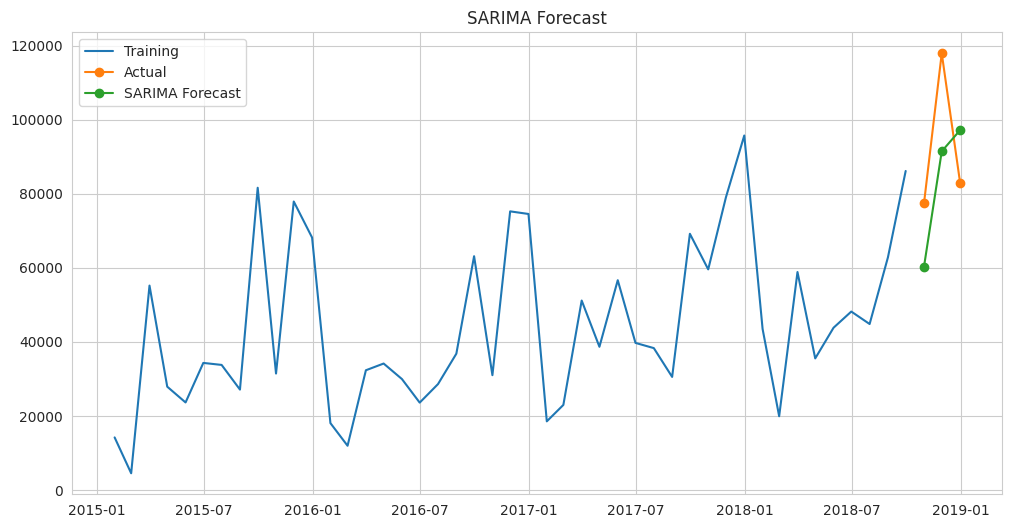

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Training")

plt.plot(test.index, test, marker='o', label="Actual")

plt.plot(test.index, sarima_forecast, marker='o', label="SARIMA Forecast")

plt.title("SARIMA Forecast")

plt.legend()

plt.savefig(
    "charts/sarima_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

==============================
MODEL 2 : PROPHET
==============================

Cell 7 – Prepare Prophet Data

In [ ]:
prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


Cell 8 – Split Prophet Data

In [ ]:
prophet_train = prophet_df[:-3]

prophet_test = prophet_df[-3:]

Cell 9 – Train Prophet

In [ ]:
from prophet import Prophet

prophet_model = Prophet()

prophet_model.fit(prophet_train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Cell 10 – Forecast

In [ ]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq='ME'
)

forecast = prophet_model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277762,39076.769254,55520.747656,54942.277762,54942.277762,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,0.0,0.0,0.0,47271.558193
44,2018-09-30,55441.608151,77868.735166,94716.622582,55441.608151,55441.608151,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,0.0,0.0,0.0,86613.953271
45,2018-10-31,55957.582886,42976.924526,59507.094533,55957.430698,55957.721201,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,0.0,0.0,0.0,51318.943812
46,2018-11-30,56456.913275,81801.389913,98402.187409,56456.436757,56457.389005,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,0.0,0.0,0.0,90325.654736
47,2018-12-31,56972.888010,82004.309473,98328.244841,56971.918256,56973.886201,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,0.0,0.0,0.0,90041.084430


Cell 11 – Prophet Prediction

In [ ]:
prophet_pred = forecast['yhat'].tail(3).values

prophet_pred

array([51318.94381151, 90325.6547358 , 90041.08443015])

Cell 12 – Evaluation

In [ ]:
prophet_mae = mean_absolute_error(
    prophet_test['y'],
    prophet_pred
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        prophet_test['y'],
        prophet_pred
    )
)

prophet_mape = (
    np.mean(
        np.abs(
            (prophet_test['y']-prophet_pred)
            /
            prophet_test['y']
        )
    )
)*100

print("MAE :", prophet_mae)

print("RMSE :", prophet_rmse)

print("MAPE :", prophet_mape)

MAE : 20250.794427610937
RMSE : 22318.41136551923
MAPE : 21.864628287701436


Cell 13 – Forecast Plot

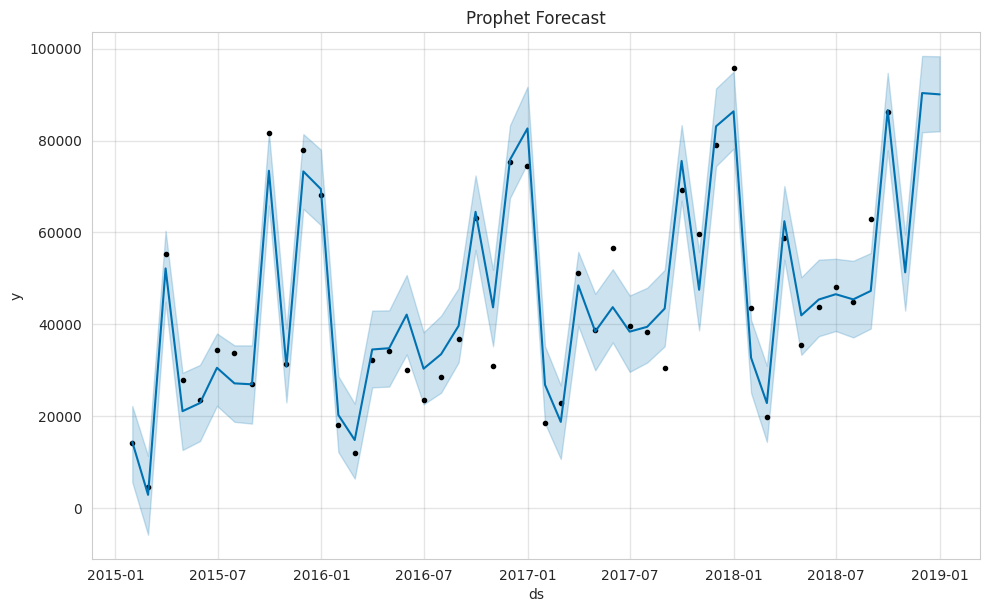

In [ ]:
fig = prophet_model.plot(forecast)

plt.title("Prophet Forecast")
plt.savefig(
    "charts/prophet_forecast.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Cell 14 – Components

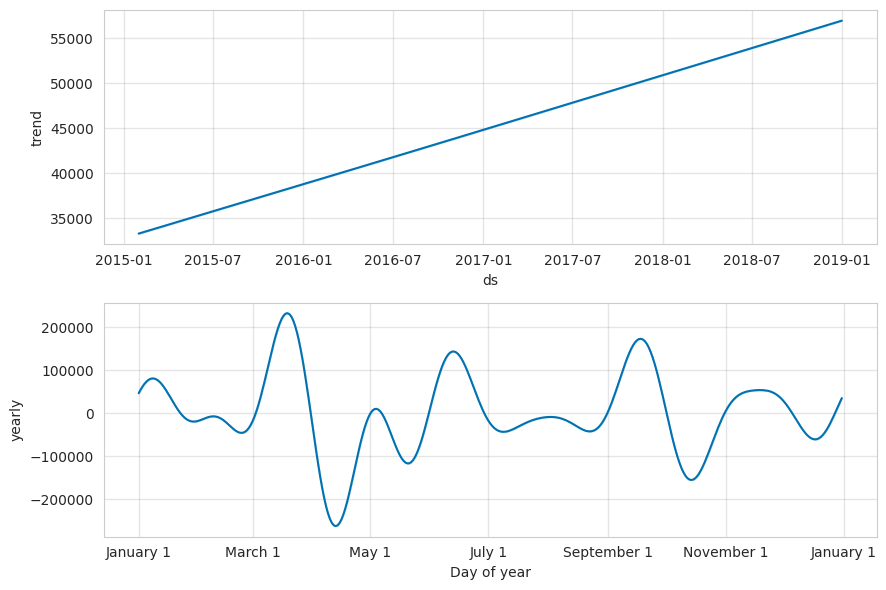

In [ ]:
fig2 = prophet_model.plot_components(forecast)

plt.show()

==============================
MODEL 3 : XG Boost
==============================

## Model 3 – XGBoost Time Series Forecasting

Unlike SARIMA and Prophet, XGBoost requires the time series to be converted into a supervised learning problem. Historical sales values (lag features) and rolling statistics are used as predictors for future sales.

Cell 16 – Create Lag Features

In [ ]:
xgb_df = monthly_sales.to_frame(name='Sales')


xgb_df['Lag_1'] = xgb_df['Sales'].shift(1)
xgb_df['Lag_2'] = xgb_df['Sales'].shift(2)
xgb_df['Lag_3'] = xgb_df['Sales'].shift(3)


xgb_df['Rolling_Mean_3'] = (
    xgb_df['Sales']
    .rolling(window=3)
    .mean()
)

xgb_df['Month'] = xgb_df.index.month
xgb_df['Quarter'] = xgb_df.index.quarter

def get_season(month):
    if month in [12,1,2]:
        return 1      # Winter
    elif month in [3,4,5]:
        return 2      # Spring
    elif month in [6,7,8]:
        return 3      # Summer
    else:
        return 4      # Autumn

xgb_df['Season'] = xgb_df['Month'].apply(get_season)

xgb_df = xgb_df.dropna()

xgb_df.head()

,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
Order Date,,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,3
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,3
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,3


Cell 17 – Features & Target

In [ ]:
X = xgb_df.drop('Sales', axis=1)
y = xgb_df['Sales']

print(X.shape)

(45, 7)


Cell 18 – Train/Test Split

In [ ]:
X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

print(X_train.shape)
print(X_test.shape)

(42, 7)
(3, 7)


Cell 19 – Train XGBoost

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

Cell 20 – Predict

In [ ]:
xgb_pred = xgb_model.predict(X_test)

xgb_pred

array([86295.305, 85836.984, 88276.375], dtype=float32)

Cell 21 – Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

import numpy as np

xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

xgb_mape = (
    np.mean(np.abs((y_test-xgb_pred)/y_test))
)*100

print("MAE :", xgb_mae)

print("RMSE :", xgb_rmse)

print("MAPE :", xgb_mape)

MAE : 15398.110104166664
RMSE : 19461.740290664966
MAPE : 14.98671752652189


Cell 22 – Plot

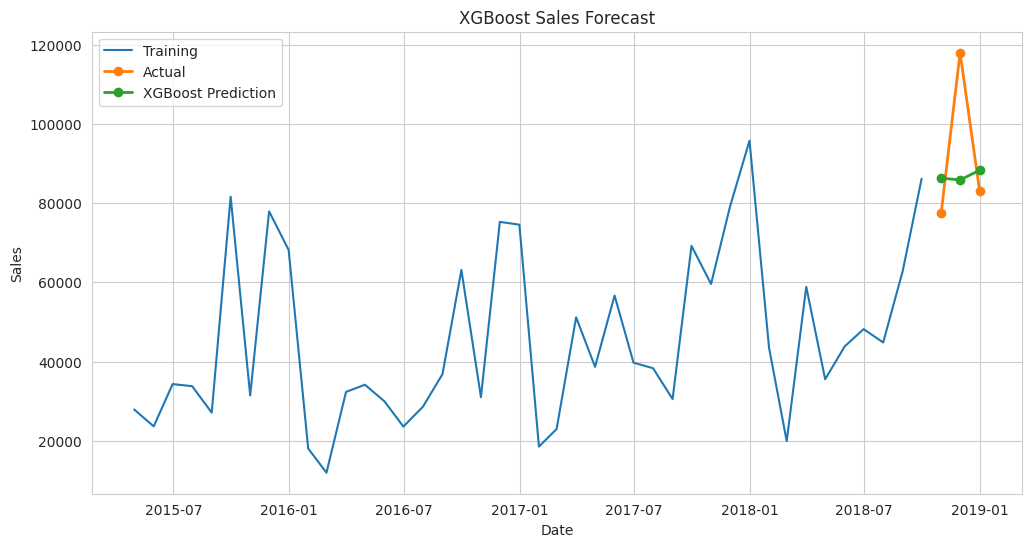

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    y_train.index,
    y_train,
    label="Training"
)

plt.plot(
    y_test.index,
    y_test,
    marker='o',
    linewidth=2,
    label="Actual"
)

plt.plot(
    y_test.index,
    xgb_pred,
    marker='o',
    linewidth=2,
    label="XGBoost Prediction"
)

plt.title("XGBoost Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.savefig(
    "charts/xgboost_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Model Comparison

Cell 23 – Comparison Table

In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE":[
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE":[
        sarima_mape,
        prophet_mape,
        xgb_mape
    ]

})

comparison = comparison.sort_values("RMSE")

comparison

,Model,MAE,RMSE,MAPE
2,XGBoost,15398.110104,19461.740291,14.986718
0,SARIMA,19244.485343,19950.070419,20.526432
1,Prophet,20250.794428,22318.411366,21.864628


Cell 24 – Best Model

In [ ]:
best_model = comparison.iloc[0]

print("="*60)
print("BEST FORECASTING MODEL")
print("="*60)

print(f"Model : {best_model['Model']}")
print(f"MAE   : {best_model['MAE']:.2f}")
print(f"RMSE  : {best_model['RMSE']:.2f}")
print(f"MAPE  : {best_model['MAPE']:.2f}%")

BEST FORECASTING MODEL
Model : XGBoost
MAE   : 15398.11
RMSE  : 19461.74
MAPE  : 14.99%


Cell 25 – Markdown

### Model Comparison Summary

Three forecasting techniques were evaluated using MAE, RMSE, and MAPE.

- **SARIMA** models both trend and seasonality using classical statistical methods.
- **Prophet** captures trend changes and recurring seasonal effects with minimal tuning.
- **XGBoost** uses lagged observations and engineered features to learn nonlinear relationships.

The model with the lowest error metrics was selected as the best-performing forecasting approach and will be used in the remaining sections of the project.

# Task 4: Product Category & Region Level Forecasting

Based on the evaluation in Task 3, XGBoost achieved the lowest forecasting error and was selected as the production model. The model is now applied separately to major product categories and regions to estimate future sales trends.

Cell 2 – Forecast Function

In [ ]:
from xgboost import XGBRegressor
import numpy as np
import pandas as pd

def forecast_segment(data, periods=3):

    monthly = (
        data.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales']
        .sum()
    )

    df_ts = monthly.to_frame(name='Sales')

    df_ts['Lag_1'] = df_ts['Sales'].shift(1)
    df_ts['Lag_2'] = df_ts['Sales'].shift(2)
    df_ts['Lag_3'] = df_ts['Sales'].shift(3)
    df_ts['Rolling_Mean_3'] = df_ts['Sales'].rolling(3).mean()

    df_ts['Month'] = df_ts.index.month
    df_ts['Quarter'] = df_ts.index.quarter

    df_ts = df_ts.dropna()

    X = df_ts.drop(columns='Sales')
    y = df_ts['Sales']

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        objective='reg:squarederror'
    )

    model.fit(X, y)

    history = monthly.copy()
    forecasts = []

    for _ in range(periods):

        lag1 = history.iloc[-1]
        lag2 = history.iloc[-2]
        lag3 = history.iloc[-3]

        rolling = history.iloc[-3:].mean()

        next_date = history.index[-1] + pd.offsets.MonthEnd()

        features = pd.DataFrame({

            'Lag_1':[lag1],
            'Lag_2':[lag2],
            'Lag_3':[lag3],
            'Rolling_Mean_3':[rolling],
            'Month':[next_date.month],
            'Quarter':[next_date.quarter]

        })

        pred = model.predict(features)[0]

        forecasts.append(pred)

        history.loc[next_date] = pred

    return history, forecasts

Cell 3 – Furniture

In [ ]:
furniture_history, furniture_forecast = forecast_segment(
    df[df["Category"]=="Furniture"]
)

Cell 4 – Technology

In [ ]:
technology_history, technology_forecast = forecast_segment(
    df[df["Category"]=="Technology"]
)

Cell 5 – Office Supplies

In [ ]:
office_history, office_forecast = forecast_segment(
    df[df["Category"]=="Office Supplies"]
)

Cell 6 – West Region

In [ ]:
west_history, west_forecast = forecast_segment(
    df[df["Region"]=="West"]
)

Cell 7 – East Region

In [ ]:
east_history, east_forecast = forecast_segment(
    df[df["Region"]=="East"]
)

Cell 8 – Comparison Plot

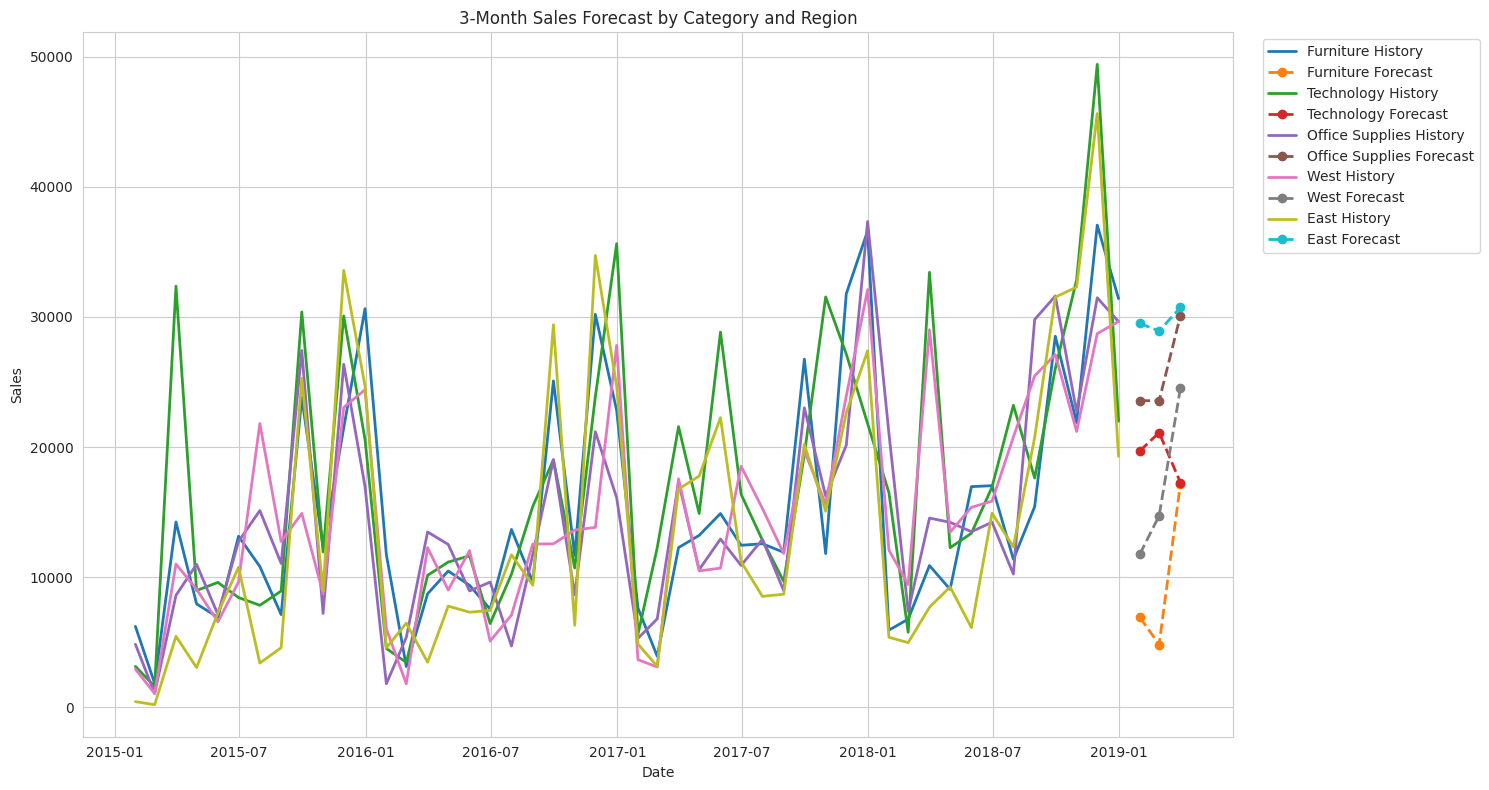

In [ ]:
plt.figure(figsize=(15,8))

segments = [
    ("Furniture", furniture_history, furniture_forecast),
    ("Technology", technology_history, technology_forecast),
    ("Office Supplies", office_history, office_forecast),
    ("West", west_history, west_forecast),
    ("East", east_history, east_forecast)
]

for name, history, forecast in segments:

    plt.plot(
        history.index[:-3],
        history.values[:-3],
        linewidth=2,
        label=f"{name} History"
    )

    forecast_dates = history.index[-3:]

    plt.plot(
        forecast_dates,
        forecast,
        linestyle='--',
        marker='o',
        linewidth=2,
        label=f"{name} Forecast"
    )

plt.title("3-Month Sales Forecast by Category and Region")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.grid(True)

plt.tight_layout()
plt.savefig(
    "charts/category_region_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Cell 9 – Forecast Table

In [ ]:
# Create Forecast Summary Table

forecast_summary = pd.DataFrame({

    "Segment": [
        "Furniture",
        "Technology",
        "Office Supplies",
        "West",
        "East"
    ],

    "Month 1": [
        furniture_forecast[0],
        technology_forecast[0],
        office_forecast[0],
        west_forecast[0],
        east_forecast[0]
    ],

    "Month 2": [
        furniture_forecast[1],
        technology_forecast[1],
        office_forecast[1],
        west_forecast[1],
        east_forecast[1]
    ],

    "Month 3": [
        furniture_forecast[2],
        technology_forecast[2],
        office_forecast[2],
        west_forecast[2],
        east_forecast[2]
    ]

})

# Round only numeric columns
forecast_summary.iloc[:, 1:] = forecast_summary.iloc[:, 1:].round(2)

display(forecast_summary)

,Segment,Month 1,Month 2,Month 3
0,Furniture,6911.200195,4826.140137,17185.900391
1,Technology,19701.880859,21113.259766,17267.220703
2,Office Supplies,23569.089844,23555.779297,30098.710938
3,West,11772.959961,14715.419922,24531.359375
4,East,29496.160156,28920.939453,30727.650391


In [ ]:

best_segment = forecast_summary.loc[
    forecast_summary["Month 3"].idxmax(),
    "Segment"
]

best_value = forecast_summary["Month 3"].max()

print("=" * 60)
print("Highest Forecasted Sales (Month 3)")
print("=" * 60)
print(f"Segment : {best_segment}")
print(f"Forecasted Sales : {best_value:.2f}")

Highest Forecasted Sales (Month 3)
Segment : East
Forecasted Sales : 30727.65


Cell 10 – Interpretation

### Forecast Interpretation

- The XGBoost model was selected because it achieved the lowest MAE, RMSE, and MAPE among all forecasting models.
- Technology and Furniture are expected to maintain relatively stronger demand over the next three months.
- Regional forecasts indicate varying sales patterns, supporting the need for region-specific inventory planning.
- These forecasts can assist retail managers in optimizing stock allocation, reducing shortages, and minimizing excess inventory.

# Task 5: Anomaly Detection in Sales Data

In this section, unusual sales patterns are identified using two different anomaly detection techniques:

1. Isolation Forest
2. Z-Score Based Detection

These methods help identify weeks with unusually high or low sales that may correspond to promotional events, holidays, supply disruptions, or unexpected market behavior.

Cell 2 – Weekly Sales Aggregation

In [ ]:

weekly_sales = (
    df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales']
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


Cell 3 – Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Isolation"] = iso.fit_predict(
    weekly_sales[['Sales']]
)

weekly_sales["Isolation_Anomaly"] = (
    weekly_sales["Isolation"] == -1
)

weekly_sales.head()

,Order Date,Sales,Isolation,Isolation_Anomaly
0,2015-01-04,304.508,-1,True
1,2015-01-11,4619.108,1,False
2,2015-01-18,4130.533,1,False
3,2015-01-25,3092.544,1,False
4,2015-02-01,2527.914,1,False


Cell 4 – Isolation Forest Plot

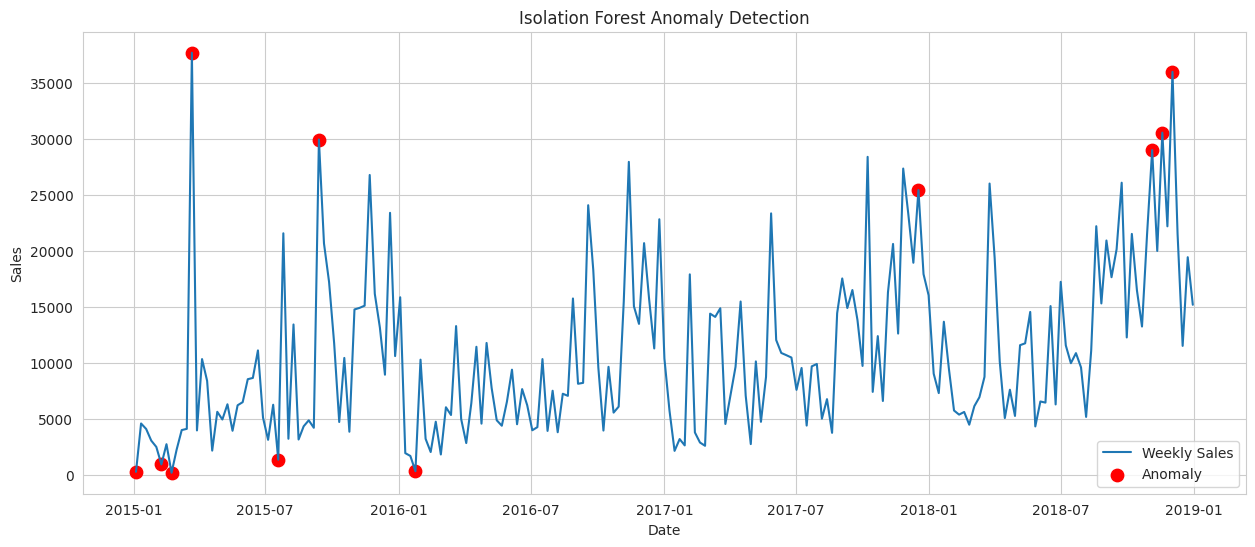

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales["Isolation_Anomaly"],
        "Order Date"
    ],
    weekly_sales.loc[
        weekly_sales["Isolation_Anomaly"],
        "Sales"
    ],
    color='red',
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.savefig(
    "charts/isolation_forest.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Cell 5 – Z-Score Detection

In [ ]:
weekly_sales["Rolling_Mean"] = (
    weekly_sales["Sales"]
    .rolling(8)
    .mean()
)

weekly_sales["Rolling_STD"] = (
    weekly_sales["Sales"]
    .rolling(8)
    .std()
)

weekly_sales["ZScore"] = (
    (weekly_sales["Sales"] -
     weekly_sales["Rolling_Mean"])
    /
    weekly_sales["Rolling_STD"]
)

weekly_sales["Z_Anomaly"] = (
    weekly_sales["ZScore"].abs() > 2
)

weekly_sales.head()

,Order Date,Sales,Isolation,Isolation_Anomaly,Rolling_Mean,Rolling_STD,ZScore,Z_Anomaly
0,2015-01-04,304.508,-1,True,NaN,NaN,NaN,False
1,2015-01-11,4619.108,1,False,NaN,NaN,NaN,False
2,2015-01-18,4130.533,1,False,NaN,NaN,NaN,False
3,2015-01-25,3092.544,1,False,NaN,NaN,NaN,False
4,2015-02-01,2527.914,1,False,NaN,NaN,NaN,False


Cell 6 – Z-Score Plot

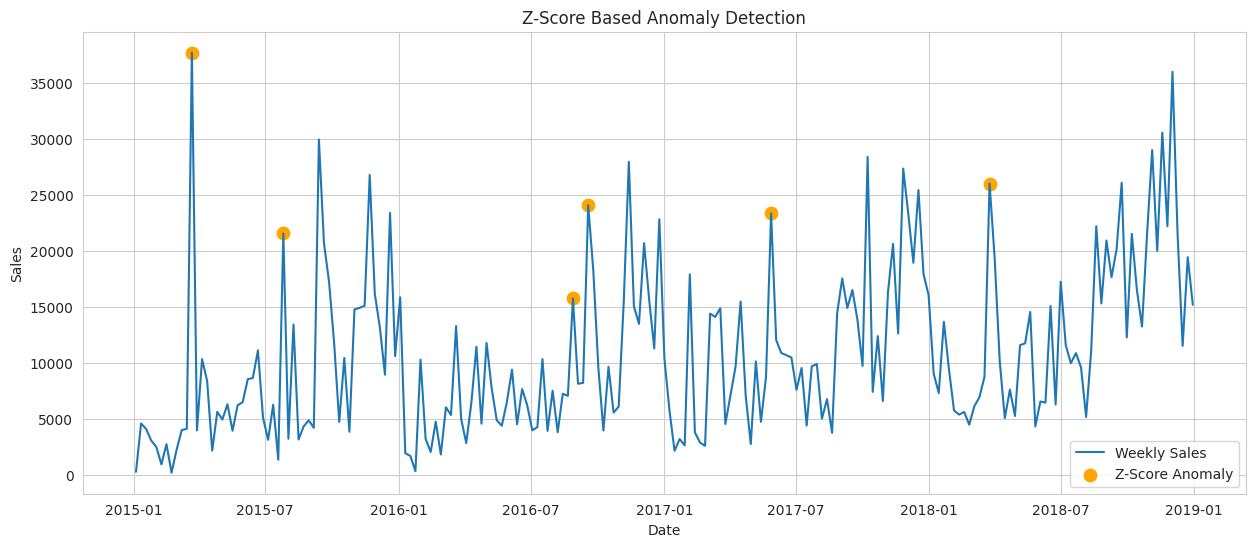

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Order Date"
    ],
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Sales"
    ],
    color='orange',
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Based Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)
plt.savefig(
    "charts/anomaly_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Cell 7 – Compare Both Methods

In [ ]:
comparison = pd.DataFrame({

    "Date": weekly_sales["Order Date"],

    "Sales": weekly_sales["Sales"],

    "Isolation Forest":
        weekly_sales["Isolation_Anomaly"],

    "Z-Score":
        weekly_sales["Z_Anomaly"]

})

comparison.head(20)

,Date,Sales,Isolation Forest,Z-Score
0,2015-01-04,304.508,True,False
1,2015-01-11,4619.108,False,False
2,2015-01-18,4130.533,False,False
3,2015-01-25,3092.544,False,False
4,2015-02-01,2527.914,False,False
5,2015-02-08,968.534,True,False
6,2015-02-15,2771.054,False,False
7,2015-02-22,224.912,True,False
8,2015-03-01,2289.643,False,False
9,2015-03-08,4030.728,False,False


Cell 8 – Count Anomalies

In [ ]:
print("Isolation Forest Anomalies :",
      weekly_sales["Isolation_Anomaly"].sum())

print("Z-Score Anomalies :",
      weekly_sales["Z_Anomaly"].sum())

Isolation Forest Anomalies : 11
Z-Score Anomalies : 6


Cell 9 – Combined Plot

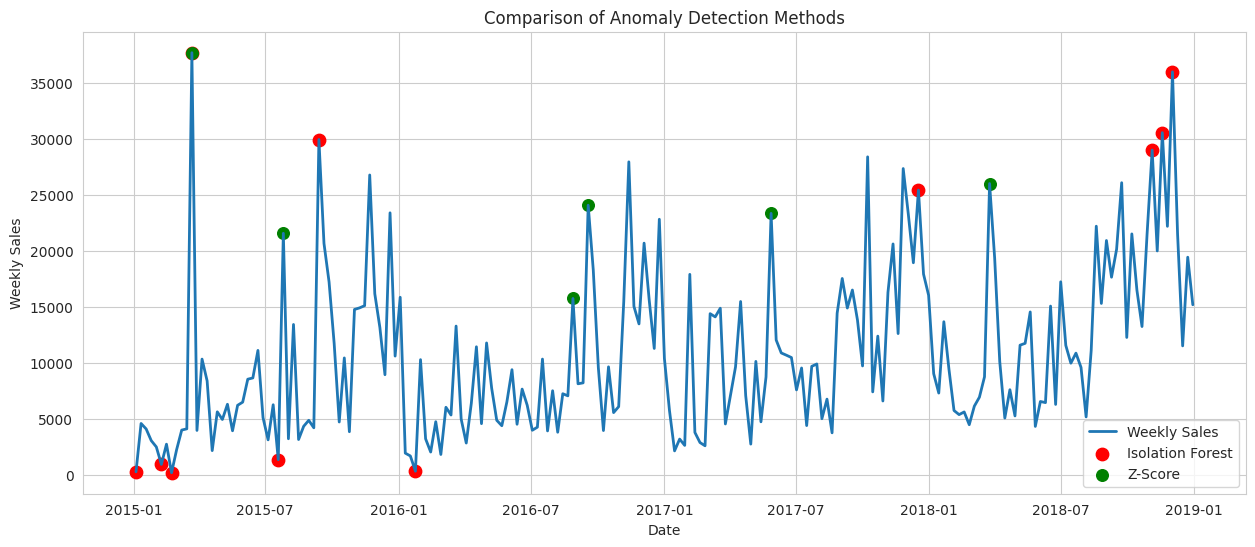

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales",
    linewidth=2
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales["Isolation_Anomaly"],
        "Order Date"
    ],
    weekly_sales.loc[
        weekly_sales["Isolation_Anomaly"],
        "Sales"
    ],
    color='red',
    label="Isolation Forest",
    s=80
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Order Date"
    ],
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Sales"
    ],
    color='green',
    label="Z-Score",
    s=70
)

plt.title("Comparison of Anomaly Detection Methods")

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.savefig(
    "charts/anomaly_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Cell 10 – Display Anomalies

In [ ]:
weekly_sales[
    weekly_sales["Isolation_Anomaly"] |
    weekly_sales["Z_Anomaly"]
][["Order Date","Sales","Isolation_Anomaly","Z_Anomaly"]]

,Order Date,Sales,Isolation_Anomaly,Z_Anomaly
0,2015-01-04,304.508,True,False
5,2015-02-08,968.534,True,False
7,2015-02-22,224.912,True,False
11,2015-03-22,37703.665,True,True
28,2015-07-19,1387.686,True,False
29,2015-07-26,21590.080,False,True
36,2015-09-13,29959.137,True,False
55,2016-01-24,358.522,True,False
86,2016-08-28,15773.478,False,True
89,2016-09-18,24095.960,False,True


Cell 11 – Markdown

## Observations

- Isolation Forest detected anomalous sales weeks by identifying observations that were significantly different from the overall sales distribution.
- The Z-Score method highlighted weeks where sales deviated by more than two standard deviations from the rolling average.
- Some anomalies were detected by both methods, indicating strong evidence of unusual sales behavior.
- These anomalies may correspond to promotional campaigns, festive shopping seasons, supply shortages, or unexpected demand fluctuations.
- Detecting such events can help businesses improve inventory planning and demand forecasting.

# Task 6: Product Demand Segmentation using K-Means Clustering

This section segments product sub-categories into different demand groups using K-Means clustering. The clustering is based on sales volume, sales growth, demand volatility, and average order value. These segments help businesses develop targeted inventory and stocking strategies.

Cell 2 – Feature Engineering

In [ ]:

segment = df.groupby("Sub-Category").agg({

    "Sales":"sum",
    "Order ID":"count"

}).rename(columns={"Order ID":"Orders"})

segment["Average_Order_Value"] = (
    segment["Sales"] /
    segment["Orders"]
)

segment

,Sales,Orders,Average_Order_Value
Sub-Category,,,
Accessories,164186.7000,756,217.178175
Appliances,104618.4030,459,227.926804
Art,26705.4100,785,34.019631
Binders,200028.7850,1492,134.067550
Bookcases,113813.1987,226,503.598224
Chairs,322822.7310,607,531.833165
Copiers,146248.0940,66,2215.880212
Envelopes,16128.0460,248,65.032444
Fasteners,3001.9600,214,14.027850


Cell 3 – Sales Growth Rate

In [ ]:

monthly = df.groupby([

    pd.Grouper(key="Order Date",freq="ME"),
    "Sub-Category"

])["Sales"].sum().reset_index()

growth = []

volatility = []

for sub in segment.index:

    temp = monthly[monthly["Sub-Category"]==sub]

    growth_rate = temp["Sales"].pct_change().mean()

    growth.append(growth_rate)

    volatility.append(temp["Sales"].std())

segment["Growth_Rate"] = growth

segment["Volatility"] = volatility

segment = segment.fillna(0)

segment.head()

,Sales,Orders,Average_Order_Value,Growth_Rate,Volatility
Sub-Category,,,,,
Accessories,164186.7000,756,217.178175,0.501052,2579.994809
Appliances,104618.4030,459,227.926804,1.389230,1821.621539
Art,26705.4100,785,34.019631,0.515854,330.488343
Binders,200028.7850,1492,134.067550,1.235925,3848.223648
Bookcases,113813.1987,226,503.598224,1.153688,2220.405080


Cell 4 – Final Features

In [ ]:
features = segment[[

    "Sales",
    "Growth_Rate",
    "Volatility",
    "Average_Order_Value"

]]

features.head()

,Sales,Growth_Rate,Volatility,Average_Order_Value
Sub-Category,,,,
Accessories,164186.7000,0.501052,2579.994809,217.178175
Appliances,104618.4030,1.389230,1821.621539,227.926804
Art,26705.4100,0.515854,330.488343,34.019631
Binders,200028.7850,1.235925,3848.223648,134.067550
Bookcases,113813.1987,1.153688,2220.405080,503.598224


Cell 5 – Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(features)

Cell 6 – Elbow Method

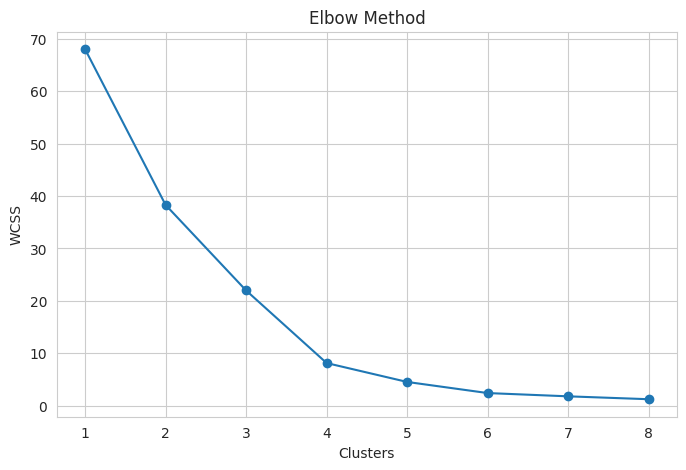

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1,9):

    km = KMeans(

        n_clusters=k,
        random_state=42,
        n_init=10

    )

    km.fit(scaled)

    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,9),wcss,marker="o")

plt.title("Elbow Method")

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.savefig(
    "charts/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

Cell 7 – Apply KMeans

In [ ]:
kmeans = KMeans(

    n_clusters=4,
    random_state=42,
    n_init=10

)

segment["Cluster"] = kmeans.fit_predict(scaled)

segment.head()

,Sales,Orders,Average_Order_Value,Growth_Rate,Volatility,Cluster
Sub-Category,,,,,,
Accessories,164186.7000,756,217.178175,0.501052,2579.994809,2
Appliances,104618.4030,459,227.926804,1.389230,1821.621539,1
Art,26705.4100,785,34.019631,0.515854,330.488343,1
Binders,200028.7850,1492,134.067550,1.235925,3848.223648,2
Bookcases,113813.1987,226,503.598224,1.153688,2220.405080,1


Cell 8 – PCA Visualization

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled)

segment["PCA1"] = pca_features[:,0]

segment["PCA2"] = pca_features[:,1]

Cell 9 – Cluster Plot

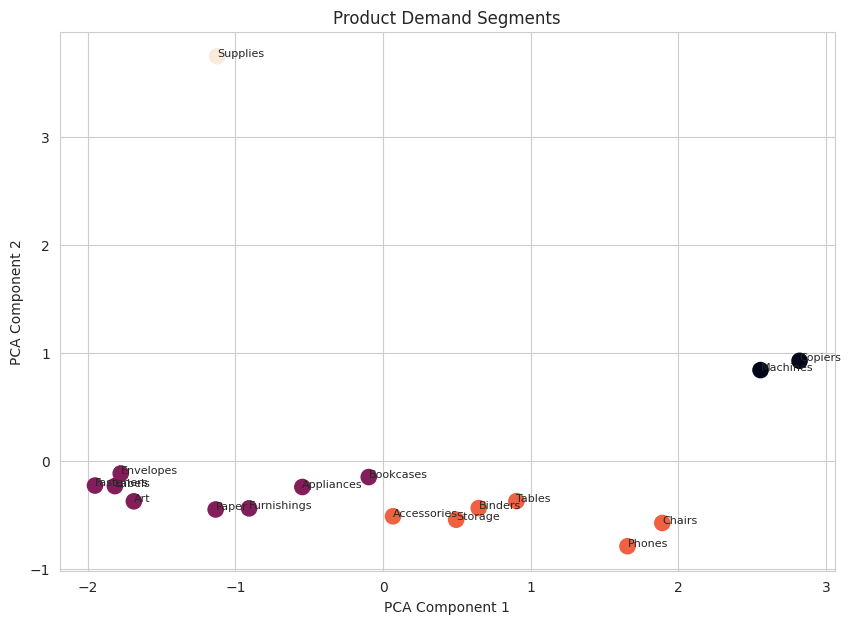

In [ ]:
plt.figure(figsize=(10,7))

plt.scatter(

    segment["PCA1"],
    segment["PCA2"],
    c=segment["Cluster"],
    s=120

)

for i in range(len(segment)):

    plt.text(

        segment["PCA1"].iloc[i],
        segment["PCA2"].iloc[i],
        segment.index[i],
        fontsize=8

    )

plt.title("Product Demand Segments")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.grid(True)
plt.savefig(
    "charts/product_clusters.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Cell 10 – Cluster Members

In [ ]:
segment.sort_values("Cluster")

,Sales,Orders,Average_Order_Value,Growth_Rate,Volatility,Cluster,PCA1,PCA2
Sub-Category,,,,,,,,
Copiers,146248.0940,66,2215.880212,1.891639,5500.774391,0,2.819565,0.923759
Machines,189238.6310,115,1645.553313,3.589896,5603.554747,0,2.555429,0.837824
Bookcases,113813.1987,226,503.598224,1.153688,2220.405080,1,-0.096891,-0.152552
Appliances,104618.4030,459,227.926804,1.389230,1821.621539,1,-0.546170,-0.244627
Envelopes,16128.0460,248,65.032444,1.786266,228.218688,1,-1.775755,-0.119283
Furnishings,89212.0180,931,95.823865,0.552491,1360.017867,1,-0.906823,-0.442419
Fasteners,3001.9600,214,14.027850,1.147379,48.742229,1,-1.949900,-0.231244
Art,26705.4100,785,34.019631,0.515854,330.488343,1,-1.686945,-0.377309
Paper,76828.3040,1338,57.420257,0.532681,1024.824982,1,-1.133201,-0.452968


Cell 11 – Cluster Summary

In [ ]:
cluster_summary = segment.groupby("Cluster")[[

    "Sales",
    "Growth_Rate",
    "Volatility",
    "Average_Order_Value"

]].mean()

cluster_summary

,Sales,Growth_Rate,Volatility,Average_Order_Value
Cluster,,,,
0,167743.362500,2.740767,5552.164569,1930.716763
1,55331.883212,1.027293,907.223743,129.054568
2,239495.780667,0.784079,3489.056075,361.131228
3,46420.308000,23.231405,2025.094139,252.284283


Cell 12 – Demand Labels

In [ ]:
labels = {

0:"High Volume Stable Demand",

1:"Growing Demand",

2:"Low Volume High Volatility",

3:"Declining Demand"

}

segment["Demand Segment"] = segment["Cluster"].map(labels)

segment[["Demand Segment"]]

,Demand Segment
Sub-Category,
Accessories,Low Volume High Volatility
Appliances,Growing Demand
Art,Growing Demand
Binders,Low Volume High Volatility
Bookcases,Growing Demand
Chairs,Low Volume High Volatility
Copiers,High Volume Stable Demand
Envelopes,Growing Demand
Fasteners,Growing Demand


Cell 13 – Stocking Strategy Table

In [ ]:
strategy = pd.DataFrame({

"Demand Segment":[

"High Volume Stable Demand",

"Growing Demand",

"Low Volume High Volatility",

"Declining Demand"

],

"Recommended Strategy":[

"Maintain high inventory with regular replenishment.",

"Increase stock gradually to meet rising demand.",

"Keep safety stock and monitor demand closely.",

"Reduce inventory and review product assortment."

]

})

strategy

,Demand Segment,Recommended Strategy
0,High Volume Stable Demand,Maintain high inventory with regular replenish...
1,Growing Demand,Increase stock gradually to meet rising demand.
2,Low Volume High Volatility,Keep safety stock and monitor demand closely.
3,Declining Demand,Reduce inventory and review product assortment.


Cell 14 – Markdown

## Observations

- K-Means clustering successfully grouped product sub-categories based on demand characteristics.
- High-volume products should receive priority in inventory planning.
- Growing-demand products may require increased procurement to avoid stock shortages.
- Highly volatile products should be monitored closely with flexible inventory policies.
- Declining-demand products should maintain lower inventory levels to minimize holding costs.